# Exercise - Model Evaluation
This exercise will focus on evaluating models' general performances through the different evaluation techniques as well as illustrate the statistical properties described in the lecture.

## Hold out method
1. Let's start by importing the librairies we will need for the exercise

In [91]:
# Load in our libraries
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import r2_score, accuracy_score
from sklearn.impute import SimpleImputer, KNNImputer
# import ensemble methods
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVR, SVC, LinearSVC
from sklearn.utils import resample

2. Let's import the iris data which will be our first object of study
create an object data that contains the explanatory variables and an object target that contains the target variable.

In [43]:
df = pd.read_csv("iris_dt.csv", names=["sepal_length", "sepal_width", "petal_length", "petal_width", "species"], header=None)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [44]:
X = df.iloc[:, :-1]
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [45]:
Y = df.iloc[:, -1]
Y

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: species, Length: 150, dtype: object

3. Split the data between a train set and a test set

In [46]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
X_train.head()

,sepal_length,sepal_width,petal_length,petal_width
137,6.4,3.1,5.5,1.8
84,5.4,3.0,4.5,1.5
27,5.2,3.5,1.5,0.2
127,6.1,3.0,4.9,1.8
132,6.4,2.8,5.6,2.2


4. Plot the distribution of the first two variables for the full data set, the train set, and the test set, do you notice any differences? what does it mean for the evaluation of our model ?

Hint: you can use plotly's [density_contour](https://plotly.com/python-api-reference/generated/plotly.express.density_contour.html)

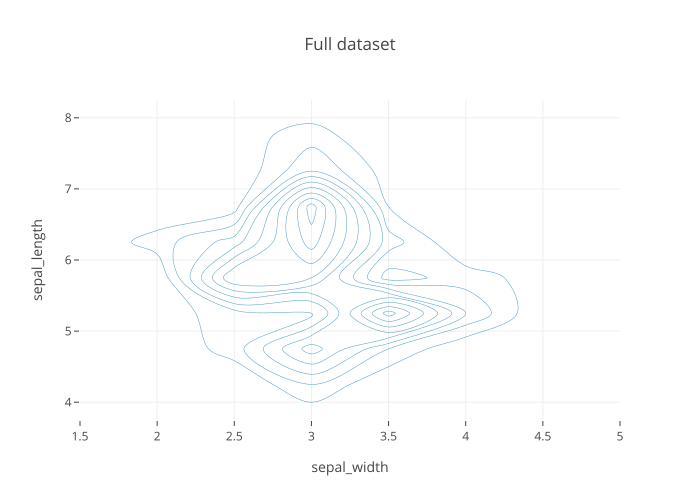

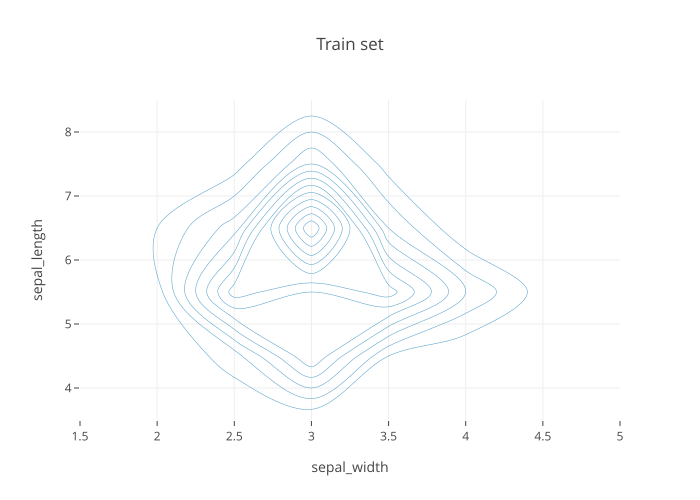

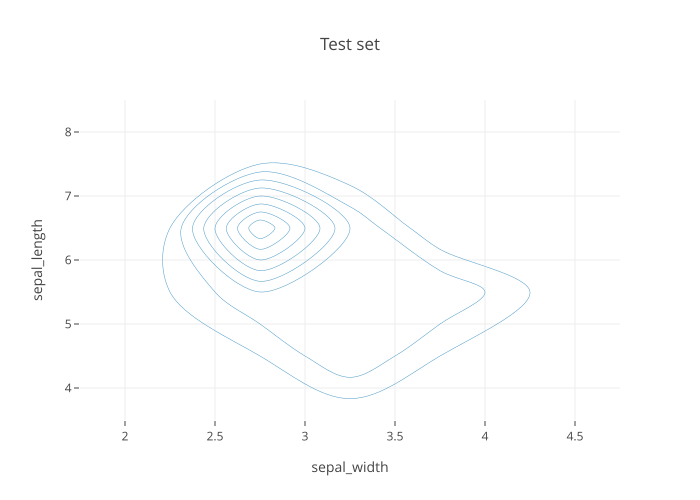

In [47]:
full_dt_distri = px.density_contour(df, x="sepal_width", y="sepal_length", title="Full dataset")
train_set_distri = px.density_contour(X_train, x="sepal_width", y="sepal_length", title="Train set")
test_set_distri = px.density_contour(X_test, x="sepal_width", y="sepal_length", title="Test set")

full_dt_distri.show()
train_set_distri.show()
test_set_distri.show()

5. Normalize the data (it is already very clean so there is no need to do other preprocessings) 

In [48]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

6. What is the baseline (dummy model) for this model? Calculate the accuracy for this baseline model.

In [49]:
# convertir y en num
encoding = LabelEncoder()
Y_train = encoding.fit_transform(Y_train)
Y_test = encoding.transform(Y_test)

In [50]:
baseline_train = np.ones_like(Y_train) * Y_train.mean()
baseline_test = np.ones_like(Y_test) * Y_train.mean()

In [ ]:
# baseline_pred = y_train.value_counts().index[0][0] # always predict the most frequent category

# print("the general score for the baseline model is : {}".format((target == baseline_pred).mean()))

The general score for the baseline train is : species  0.0
The general score for the baseline test is: -0.08054123711340222


7. Create an instance of a SVM model with a linear kernel, calculate the resubstitution score and hold out score for this model. What can you say about the bias for each of these evaluation metrics?

In [52]:
svm = LinearSVC()
svm.fit(X_train, Y_train)

print("The resubstitution score for the SVC linear model is :", svm.score(X_train, Y_train))
print("The hold out score for the SVC linear model is :", svm.score(X_test, Y_test))

The resubstitution score for the SVC linear model is : 0.9416666666666667
The hold out score for the SVC linear model is : 0.9666666666666667


8. Look at the distribution of the target variable in the full dataset, the train set and the test set. Are they identically distributed?

In [53]:
full_distribution = df['species'].value_counts(normalize=True).sort_index()
print("The distribution for the target on the full dataset is : ", full_distribution)
train_distribution = pd.Series(Y_train).value_counts(normalize=True).sort_index()
print("The distribution for the target on the train set is : ", train_distribution)
test_distribution =pd.Series(Y_test).value_counts(normalize=True).sort_index()
print("The distribution for the target on the test set is : ", test_distribution)

The distribution for the target on the full dataset is :  species
Iris-setosa        0.333333
Iris-versicolor    0.333333
Iris-virginica     0.333333
Name: proportion, dtype: float64
The distribution for the target on the train set is :  0    0.325000
1    0.308333
2    0.366667
Name: proportion, dtype: float64
The distribution for the target on the test set is :  0    0.366667
1    0.433333
2    0.200000
Name: proportion, dtype: float64


9. Perform a new train test split and this time make sure that the target variable's distribution is preserved.

In [54]:
X_train_s, X_test_s, Y_train_s, Y_test_s = train_test_split(X, Y, test_size=0.2, random_state=0, stratify=Y)
Y_train_s = encoding.fit_transform(Y_train_s)
Y_test_s = encoding.transform(Y_test_s)
full_distribution = df['species'].value_counts(normalize=True).sort_index()
print("The distribution for the target on the full dataset is : ", full_distribution)
train_distribution_s = pd.Series(Y_train_s).value_counts(normalize=True).sort_index()
print("The distribution for the target on the train set is : ", train_distribution_s)
test_distribution_s=pd.Series(Y_test_s).value_counts(normalize=True).sort_index()
print("The distribution for the target on the test set is : ", test_distribution_s)

The distribution for the target on the full dataset is :  species
Iris-setosa        0.333333
Iris-versicolor    0.333333
Iris-virginica     0.333333
Name: proportion, dtype: float64
The distribution for the target on the train set is :  0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64
The distribution for the target on the test set is :  0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64


10. What was the influence of this operation on the distribution of the explanatory variables?

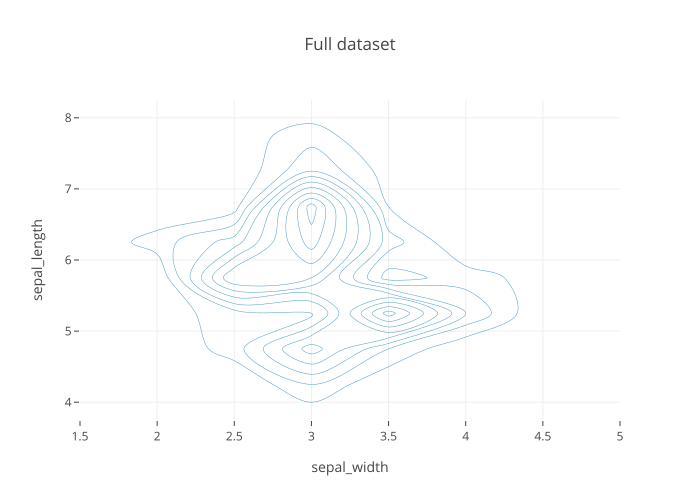

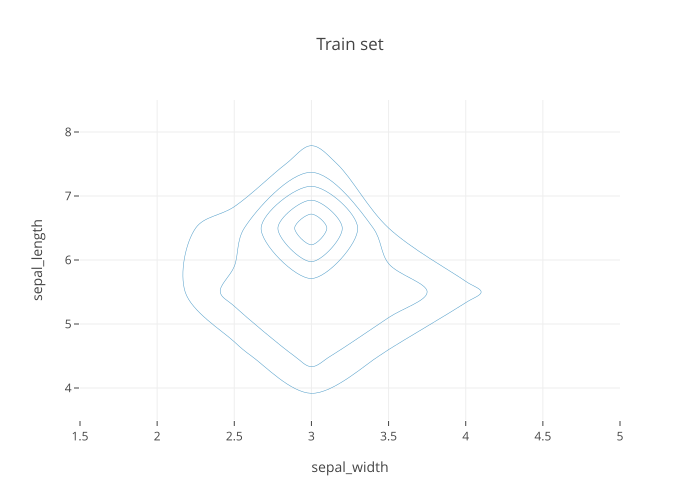

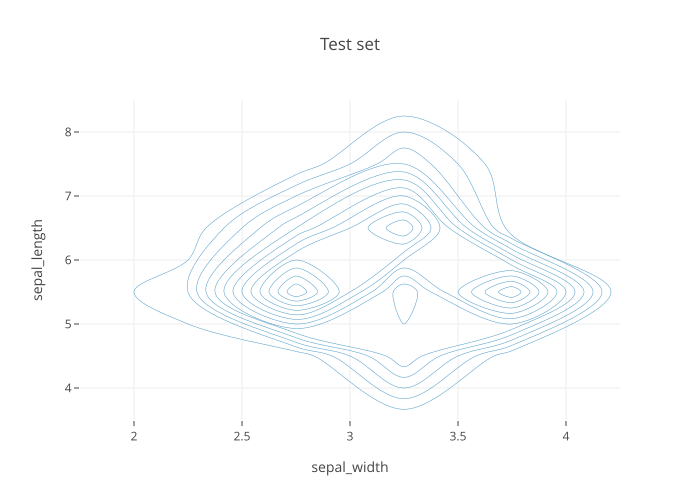

In [ ]:
full_dt_distri = px.density_contour(df, x="sepal_width", y="sepal_length", title="Full dataset")
train_set_distri_s = px.density_contour(X_train_s, x="sepal_width", y="sepal_length", title="Train set")
test_set_distri_s = px.density_contour(X_test_s, x="sepal_width", y="sepal_length", title="Test set")

full_dt_distri.show()
train_set_distri_s.show()
test_set_distri_s.show()

11. Calculate the new resubstitution score and holdout score for the new stratified split. What is the influence of stratifying data on the bias of each evaluation metric?

In [55]:
svm.fit(X_train, Y_train)

print("The resubstitution score for the SVC linear model is :", svm.score(X_train, Y_train))
print("The hold out score for the SVC linear model is :", svm.score(X_test, Y_test))

The resubstitution score for the SVC linear model is : 0.9416666666666667
The hold out score for the SVC linear model is : 0.9666666666666667


In [56]:
svm.fit(X_train_s, Y_train_s)

print("The resubstitution score for the SVC linear model is :", svm.score(X_train_s, Y_train_s))
print("The hold out score for the SVC linear model is :", svm.score(X_test_s, Y_test_s))

The resubstitution score for the SVC linear model is : 0.975
The hold out score for the SVC linear model is : 0.9666666666666667


12. Create a loop that will repeat 100 times the hold out method for the non-stratified and the stratified splits respectively, then calculate the average score in both cases, the standard deviation and the 95% confidence intervals. Plot the resusbstitution and hold out score distribution for both cases, what can you conclude ?

In [86]:
# Initialiser les listes pour stocker les scores
resubstitution_non_strat = []
holdout_non_strat = []
resubstitution_strat = []
holdout_strat = []
model = LinearSVC()
# Boucle 100 fois
for i in range(100):
    # Non-stratified split
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=i)
    model.fit(X_train, Y_train)
    # Resubstitution score (sur train)
    Y_pred = model.predict(X_test)
    resubstitution_non_strat.append(accuracy_score(Y_test, Y_pred))
    # Hold-out score (sur test)
    Y_pred_test = model.predict(X_test)
    holdout_non_strat.append(accuracy_score(Y_test, Y_pred_test))
    
    # Stratified split
    X_train_s, X_test_s, Y_train_s, Y_test_s = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=i)
    model.fit(X_train_s, Y_train_s)
    # Resubstitution score (sur train)
    Y_pred_s = model.predict(X_test_s)
    resubstitution_strat.append(accuracy_score(Y_test_s, Y_pred_s))
    # Hold-out score (sur test)
    Y_pred_s_test = model.predict(X_test_s)
    holdout_strat.append(accuracy_score(Y_test_s, Y_pred_s_test))

# Convertir en numpy arrays
resubstitution_non_strat = np.array(resubstitution_non_strat)
holdout_non_strat = np.array(holdout_non_strat)
resubstitution_strat = np.array(resubstitution_strat)
holdout_strat = np.array(holdout_strat)

# print(resubstitution_non_strat[:2])
# print(holdout_non_strat[:2])
# print(resubstitution_strat[:2])
# print(holdout_strat[:2])

In [87]:
print("The average resubstitution score for the non stratified data is : ", resubstitution_non_strat.mean())
print("The standard deviation of the resubstitution score for the non stratified data is : ", resubstitution_non_strat.std().round(2))
print(f"The 95 percent confidence interval of the resubstitution score for the non stratified data is [{resubstitution_non_strat.mean() - resubstitution_non_strat.std()},{resubstitution_non_strat.mean() + resubstitution_non_strat.std()}]:") 
print()
print("The average hold out score for the non stratified data is : ", holdout_non_strat.mean().round(2))
print("The standard deviation of the hold out score for the non stratified data is : ", holdout_non_strat.std().round(2) )
print(f"The 95 percent confidence interval of the hold out score for the non stratified data is : [{holdout_non_strat.mean() - holdout_non_strat.std()}, {holdout_non_strat.mean() + holdout_non_strat.std()}]")
print()
print("The average resubstitution score for the stratified data is : ", resubstitution_strat.mean())
print("The standard deviation of the resubstitution score for the stratified data is : ", resubstitution_strat.std().round(2))
print(f"The 95 percent confidence interval of the resubstitution score for the stratified data is : [{resubstitution_non_strat.mean() - resubstitution_non_strat.std()},{resubstitution_non_strat.mean() + resubstitution_non_strat.std()}]:")
print()
print("The average hold out score for the stratified data is : ", holdout_strat.mean().round(2))
print("The standard deviation of the hold out score for the stratified data is : ", holdout_strat.std().round(2))
print(f"The 95 percent confidence interval of the hold out score for the stratified data is : [{holdout_non_strat.mean() - holdout_non_strat.std()}, {holdout_non_strat.mean() + holdout_non_strat.std()}]")

The average resubstitution score for the non stratified data is :  0.9470000000000002
The standard deviation of the resubstitution score for the non stratified data is :  0.04
The 95 percent confidence interval of the resubstitution score for the non stratified data is [0.9030063135842832,0.9909936864157172]:

The average hold out score for the non stratified data is :  0.95
The standard deviation of the hold out score for the non stratified data is :  0.04
The 95 percent confidence interval of the hold out score for the non stratified data is : [0.9030063135842832, 0.9909936864157172]

The average resubstitution score for the stratified data is :  0.9583333333333335
The standard deviation of the resubstitution score for the stratified data is :  0.04
The 95 percent confidence interval of the resubstitution score for the stratified data is : [0.9030063135842832,0.9909936864157172]:

The average hold out score for the stratified data is :  0.96
The standard deviation of the hold out sco

In [88]:
resubstitution_strat

array([0.96666667, 1.        , 1.        , 0.93333333, 1.        ,
       0.93333333, 1.        , 0.96666667, 0.96666667, 0.93333333,
       0.96666667, 1.        , 1.        , 1.        , 0.96666667,
       0.9       , 1.        , 0.96666667, 0.9       , 1.        ,
       1.        , 0.96666667, 0.93333333, 0.93333333, 1.        ,
       0.86666667, 1.        , 0.9       , 1.        , 1.        ,
       0.86666667, 0.93333333, 0.93333333, 0.96666667, 0.96666667,
       0.96666667, 0.96666667, 0.9       , 0.96666667, 0.93333333,
       0.9       , 0.9       , 0.96666667, 0.93333333, 0.96666667,
       0.93333333, 0.93333333, 0.86666667, 0.96666667, 0.96666667,
       1.        , 0.96666667, 0.93333333, 0.96666667, 0.96666667,
       0.96666667, 0.9       , 0.96666667, 0.93333333, 0.96666667,
       0.96666667, 1.        , 0.96666667, 0.93333333, 0.96666667,
       0.9       , 0.96666667, 0.86666667, 0.93333333, 0.96666667,
       0.96666667, 0.96666667, 1.        , 1.        , 0.93333

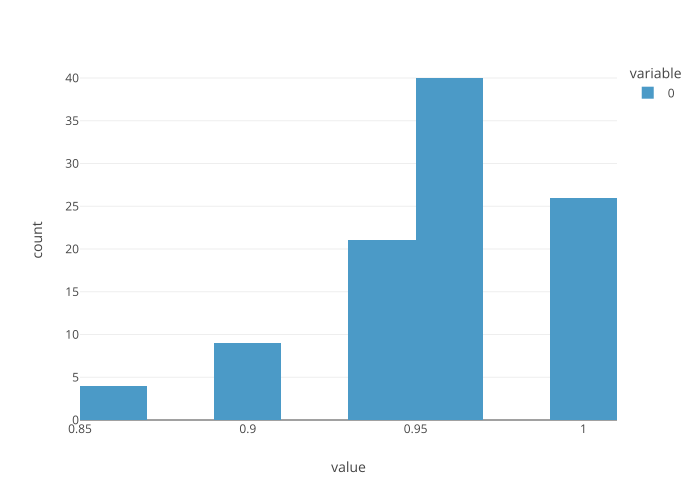

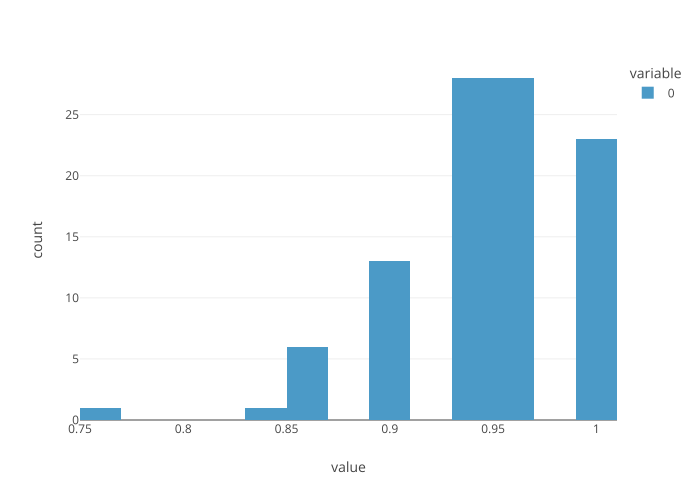

In [90]:
fig = px.histogram(resubstitution_strat)
fig.show()

fig2 = px.histogram(resubstitution_non_strat)
fig2.show()

## Bootstrap Method
This section of the exercise will keep using the iris dataset and implement the bootstrap evaluation techniques that were introduced in the lecture

1. First let's use the ```sklearn.utils.resample``` function to create 100 bootstrap samples (don't forget to also generate the out of bag samples)

In [93]:
resample(X, n_samples=150)

,sepal_length,sepal_width,petal_length,petal_width
123,6.3,2.7,4.9,1.8
139,6.9,3.1,5.4,2.1
141,6.9,3.1,5.1,2.3
119,6.0,2.2,5.0,1.5
101,5.8,2.7,5.1,1.9
...,...,...,...,...
142,5.8,2.7,5.1,1.9
88,5.6,3.0,4.1,1.3
103,6.3,2.9,5.6,1.8
90,5.5,2.6,4.4,1.2


In [107]:
Y = encoding.fit_transform(Y)
X_boot, y_boot = resample(X, Y, n_samples=150, random_state=0)
#Pour les OOB, il faut recréer les mêmes indices
rng = np.random.RandomState(0)  # Reset avec le même seed
boot_indices = rng.choice(len(X), size=150, replace=True)
oob_indices = np.setdiff1d(range(len(X)), boot_indices)

X_oob = X.iloc[oob_indices]
y_oob = Y[oob_indices]
print("first bootstrap sample : ", X_boot)
print()
print("First out of bag sample :", X_oob)
print()
print("first bootstrap sample target : ", y_boot)
print()
print("first out of bag sample target : ", y_oob)

first bootstrap sample :       sepal_length  sepal_width  petal_length  petal_width
47            4.6          3.2           1.4          0.2
117           7.7          3.8           6.7          2.2
67            5.8          2.7           4.1          1.0
103           6.3          2.9           5.6          1.8
9             4.9          3.1           1.5          0.1
..            ...          ...           ...          ...
4             5.0          3.6           1.4          0.2
139           6.9          3.1           5.4          2.1
86            6.7          3.1           4.7          1.5
121           5.6          2.8           4.9          2.0
109           7.2          3.6           6.1          2.5

[150 rows x 4 columns]

First out of bag sample :      sepal_length  sepal_width  petal_length  petal_width
5             5.4          3.9           1.7          0.4
7             5.0          3.4           1.5          0.2
8             4.4          2.9           1.4         

2. Let's normalize each couple of bootstrap and out of bag samples

In [108]:
print("first normalised bootstrap sample :")
X_boot = sc.fit_transform(X_boot)
X_boot

first normalised bootstrap sample :


array([[-1.45714057,  0.31508217, -1.27626425, -1.24468572],
       [ 2.36446329,  1.74727383,  1.72028057,  1.29376238],
       [ 0.02218996, -0.87841089,  0.25027745, -0.22930648],
       [ 0.63857768, -0.40101367,  1.09835618,  0.78607276],
       [-1.08730794,  0.07638356, -1.21972566, -1.37160812],
       [-0.84075285,  1.50857522, -1.21972566, -0.99084091],
       [-0.34764267,  1.031178  , -1.33280283, -1.24468572],
       [ 0.63857768, -1.83320533,  0.4198932 ,  0.15146074],
       [ 0.1454675 ,  0.31508217,  0.64604752,  0.78607276],
       [-0.22436513, -0.16231506,  0.25027745,  0.15146074],
       [ 1.13168785,  0.07638356,  1.09835618,  1.54760719],
       [ 1.00841031, -0.40101367,  0.53297036,  0.15146074],
       [-0.84075285,  0.79247939, -1.21972566, -1.24468572],
       [ 0.63857768, -1.83320533,  0.4198932 ,  0.15146074],
       [-0.22436513, -0.16231506,  0.25027745,  0.15146074],
       [-0.34764267, -1.59450672,  0.02412313, -0.22930648],
       [-0.96403039, -0.

3. Let's now train the svc linear model on our bootstrap samples, create a list of resubstitution scores on the bootstrap samples and a list of out of bag scores. And plot the distributions of both scores, what do you think? is it coherent with the lecture ?

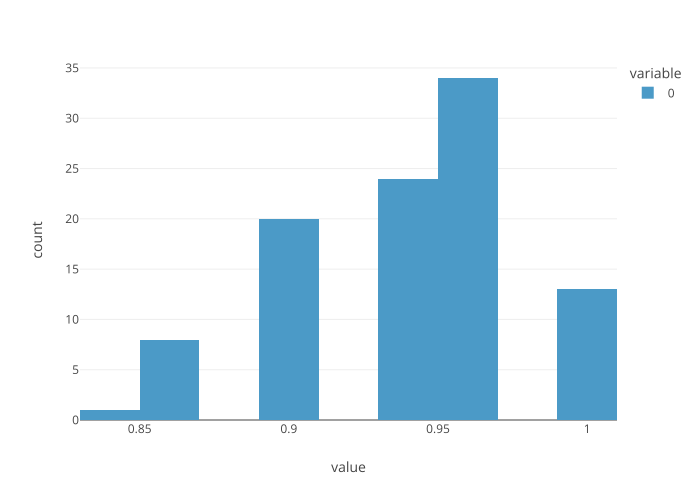

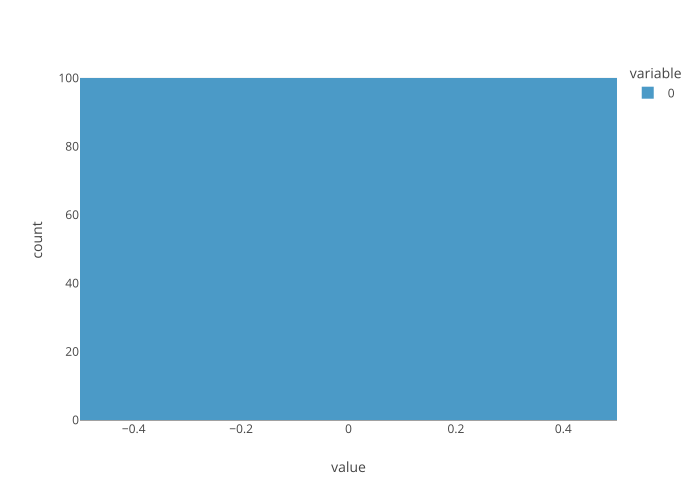

In [110]:
resubstitution_boot_strat = []
holdout_boot_strat = []
for i in range(100):
    X_boot_train, X_boot_test, Y_boot_train, Y_boot_test = train_test_split(X_boot, y_boot, test_size=0.2, random_state=i)
    model.fit(X_boot_train, Y_boot_train)
    # Resubstitution score (sur train)
    Y_boot_pred = model.predict(X_boot_test)
    resubstitution_boot_strat.append(accuracy_score(Y_boot_test, Y_boot_pred))
    # Hold-out score (sur test)
    Y_pred_test = model.predict(X_test)
    holdout_boot_strat.append(accuracy_score(Y_test, Y_pred_test))

fig3 = px.histogram(resubstitution_boot_strat)
fig3.show()

fig4 = px.histogram(holdout_boot_strat)
fig4.show()

4. Calculate the boostrap accuracy using the following formula from the lecture :
$$ACC_{bootstrap} = \frac{1}{b}\sum_{i=1}^{b}(0.632\times ACC_{h,i} + 0.368\times ACC_{r,i})$$


In [114]:
type(resubstitution_boot_strat)

list

In [115]:
ACCr = np.mean(resubstitution_boot_strat)
ACCh = np.mean(holdout_boot_strat)
ACCbootstrap = 0.632*ACCh + 0.368*ACCr
print("The boostrap score gives the following average : ", ACCbootstrap )
print("Its standard deviation is : ", ACCbootstrap.std().round(2))
print(f" Its 95 percent confidence interval is :  [{ACCbootstrap - ACCbootstrap.std()},{ACCbootstrap.mean() + ACCbootstrap.std()}]:") 
print()

The boostrap score gives the following average :  0.3460426666666667
Its standard deviation is :  0.0
 Its 95 percent confidence interval is :  [0.3460426666666667,0.3460426666666667]:



## Cross Validation and Hyper Parameter optimization
This last section of the exercise will focus on model evaluation through cross validation 

### K Fold grid search cross validation
1. Import the digits dataset from sklearn

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

2. This dataset contains images, it should not be normalized using Standard Scaler as this would change the constrast in the pictures and potentially add a lot of unwanted noise to the data. Instead we will simply divide each pixel value by 255 to work with values between 0 and 1.
Since this operation does not rely on data distribution you may apply it directly on the full dataset

array([[0.        , 0.        , 0.01960784, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.03921569, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.0627451 , 0.03529412,
        0.        ],
       ...,
       [0.        , 0.        , 0.00392157, ..., 0.02352941, 0.        ,
        0.        ],
       [0.        , 0.        , 0.00784314, ..., 0.04705882, 0.        ,
        0.        ],
       [0.        , 0.        , 0.03921569, ..., 0.04705882, 0.00392157,
        0.        ]])

3. We are now going to start the process of determining the best set of hyper parameters for two different models through cross validation. Start by separating the dataset into a train and test set. Make sure to stratify the split according to the target variable.

4. Create an instance of an SVM model and an instance of a random forest model

5. Run a grid search cross validation process in order to determine the best set of parameters for both these models. (set ```return_train_scores=True```)

CPU times: user 11.9 s, sys: 2.2 ms, total: 11.9 s
Wall time: 11.9 s
CPU times: user 5min 39s, sys: 1.61 s, total: 5min 40s
Wall time: 5min 41s


GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': array([ 3,  5,  7,  9, 11, 13, 15]),
                         'n_estimators': array([  1,  51, 101, 151, 201, 251, 301, 351, 401, 451, 501, 551])},
             return_train_score=True)

6. What set of parameters was identified to be the best for each model?

the best set of parameters for the svm model is : 
 {'C': 10.0, 'kernel': 'rbf'} 
 the best set of parameters for the random forest is : 
 {'max_depth': 11, 'n_estimators': 51} 


7. Compare the distribution of train and test scores for the best svm and best random forest model

Train scores for svc best model are : 
 [1.0, 1.0, 1.0, 1.0, 1.0] 
 Train scores for rf best model are : 
 [1.0, 1.0, 1.0, 1.0, 1.0] 
 
 Test scores for svc best model are : 
 [0.9777777777777777, 0.9814814814814815, 0.9776951672862454, 0.9962825278810409, 0.9962825278810409] 
 Test scores for rf best model are : 
 [0.9888888888888889, 0.9703703703703703, 0.9776951672862454, 0.9628252788104089, 0.966542750929368]


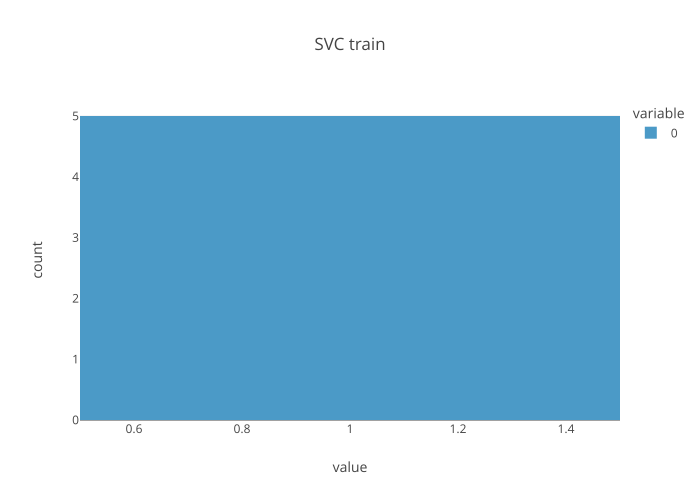

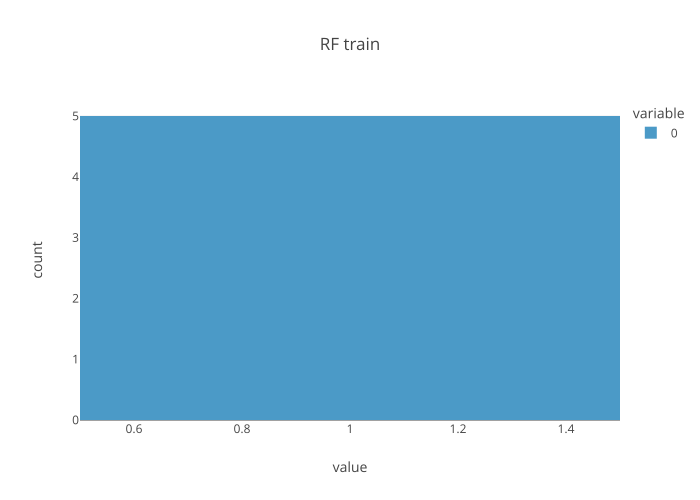

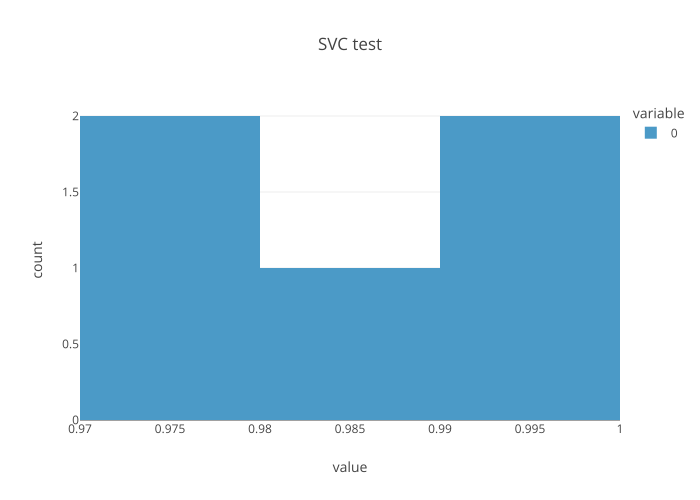

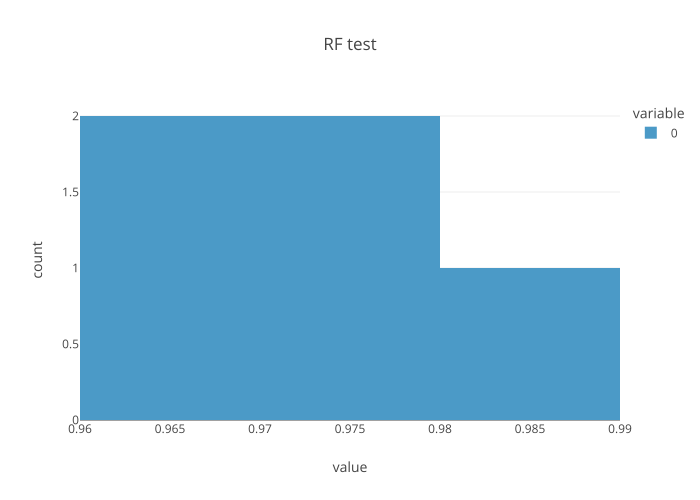

8. Now compute the scores of both best models on the hold out test set, are the results coherent with those of the cross validation ?

best svc score on the hold out test set : 
 0.9933333333333333 
 best rf score on the hold out test set : 
 0.9688888888888889


### Three way hold out method
9. To finish off the exercise, we are going to compare the cross validation technique with the three way hold out method which is indicated for very large dataset (it is not ideal theoretically speaking but it saves a lot of computing power and execution time)
Run a grid search cv across the same parameter grids as before but impose the train validation split by setting the argument ```cv=zip([train_index],[valid_index])``` the train and valid indexes need to be taken from the original train set from the first split, we will use the test set at the end to compare scores.
Also make sure to measure the execution time for each training.

CPU times: user 1.31 s, sys: 997 µs, total: 1.31 s
Wall time: 1.31 s
CPU times: user 1min, sys: 337 ms, total: 1min 1s
Wall time: 1min 1s


GridSearchCV(cv=<zip object at 0x7f5722b83a40>,
             estimator=RandomForestClassifier(),
             param_grid={'max_depth': array([ 3,  5,  7,  9, 11, 13, 15]),
                         'n_estimators': array([  1,  51, 101, 151, 201, 251, 301, 351, 401, 451, 501, 551])})

10. What are the best parameters for each model ?

the best set of parameters for the svm model is : 
 {'C': 1.0, 'kernel': 'rbf'} 
 the best set of parameters for the random forest is : 
 {'max_depth': 11, 'n_estimators': 251} 


11. Calculate the final score for each model using the hold out test set, what can you conclude about the k-fold method vs the three way hold out method?

best svc score on the hold out test set : 
 0.9933333333333333 
 best rf score on the hold out test set : 
 0.9822222222222222
